In [1]:
import os
import sys
src_path = '../../../src'
if src_path not in sys.path:
    sys.path.append(src_path)
import numpy as np
import pandas as pd
from configs import SetupEnum, MeasurementDataEnum, SamplingEnum
from kalman_filters.particle_filter import ResamplingAlgorithms
from parameter_tuners.particle_filter_parameter_tuner import ParticleFilterParameterTuner


%matplotlib inline
np.random.seed(777)

In [3]:
# n_samples = np.logspace(1.0, 4.0, num=10).tolist()
algorithms = [ResamplingAlgorithms.MULTINOMIAL, 
              ResamplingAlgorithms.RESIDUAL, 
              ResamplingAlgorithms.STRATIFIED, 
              ResamplingAlgorithms.SYSTEMATIC]
# n_samples = np.logspace(1.0, 4.0, num=4).tolist()
n_samples = [int(n) for n in np.logspace(5, 12, base=2, num=8).tolist()]

params = {
    "n_samples": n_samples,
    "algorithms": algorithms,
}
n_samples

[32, 64, 128, 256, 512, 1024, 2048, 4096]

In [ ]:
resampling_algorithm_str = {
    ResamplingAlgorithms.MULTINOMIAL: "MULTINOMIAL", 
    ResamplingAlgorithms.RESIDUAL: "RESIDUAL", 
    ResamplingAlgorithms.STRATIFIED: "STRATIFIED", 
    ResamplingAlgorithms.SYSTEMATIC: "SYSTEMATIC"
}

file_export_path = "../exports/unscented_kalman_filter"
kitti_dataset = "0033"

upsampling_factor = 5

error_weight = 0.8

In [4]:
best_params = []
best_params_0 = []
best_params_10 = []
best_params_20 = []
best_params_30 = []
best_params_40 = []

------

# No dropout measurement data

## Setup1 (IMU, VO)

In [5]:
tuner_setup1 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    measurement_type=MeasurementDataEnum.ALL_DATA,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)
tuner_setup1.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [6]:
tuner_setup1.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:50<00:00, 28.75s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:51<00:00, 28.90s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.10s/it]


Resampling by $SYSTEMATIC


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [15:24<00:00, 115.58s/it]

Experiment finished.


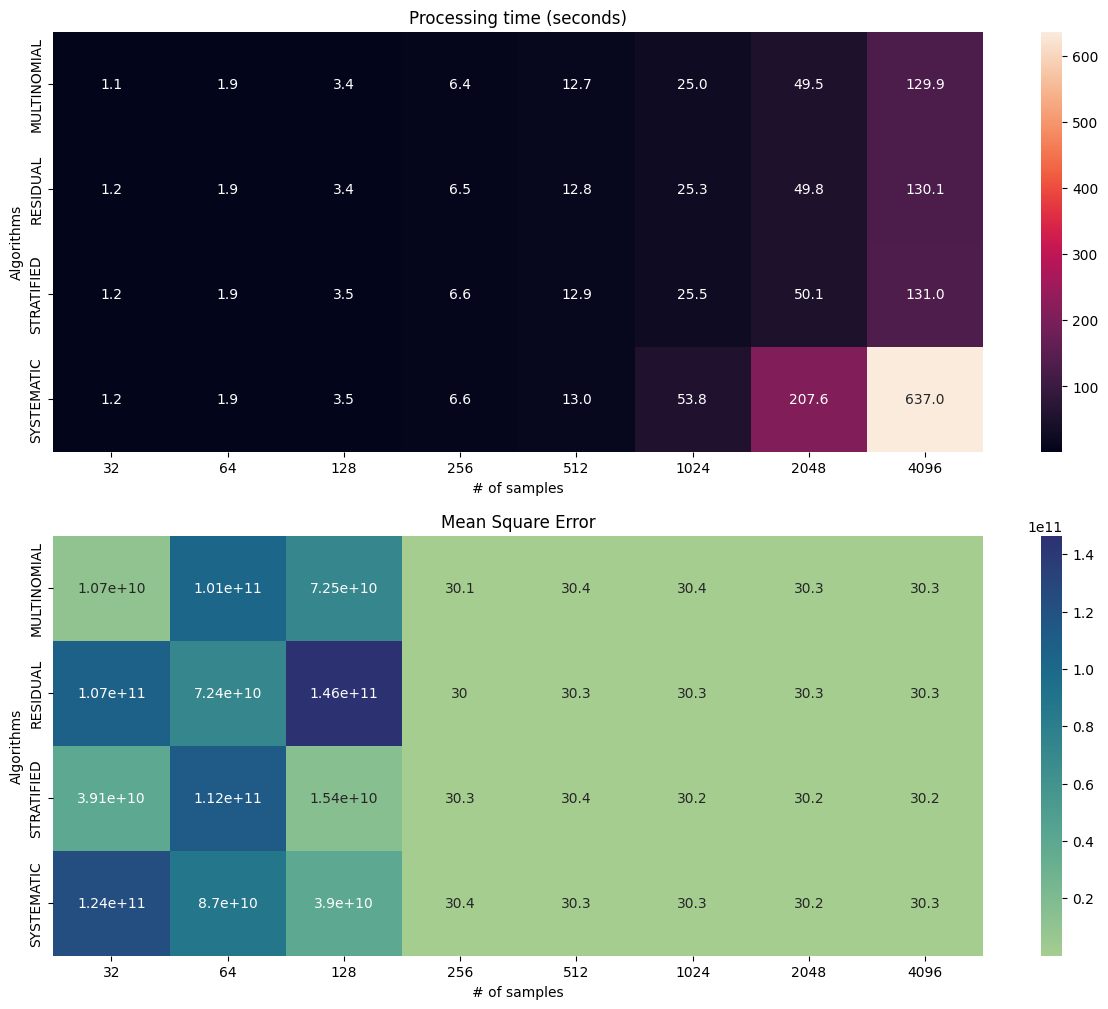

In [7]:
tuner_setup1.plot_results()

In [8]:
n_setup1_0, algorithm_setup1_0 = tuner_setup1.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append([n_setup1_0, resampling_algorithm_str[algorithm_setup1_0]])

Optimal model index: 11
Optimal model error: 29.988 and processing time: 6.5
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.RESIDUAL


## Setup2 (IMU, VO+GPS)

In [9]:
tuner_setup2 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)
tuner_setup2.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [10]:
tuner_setup2.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:46<00:00, 50.83s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:46<00:00, 50.77s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:44<00:00, 50.62s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:44<00:00, 50.61s/it]

Experiment finished.


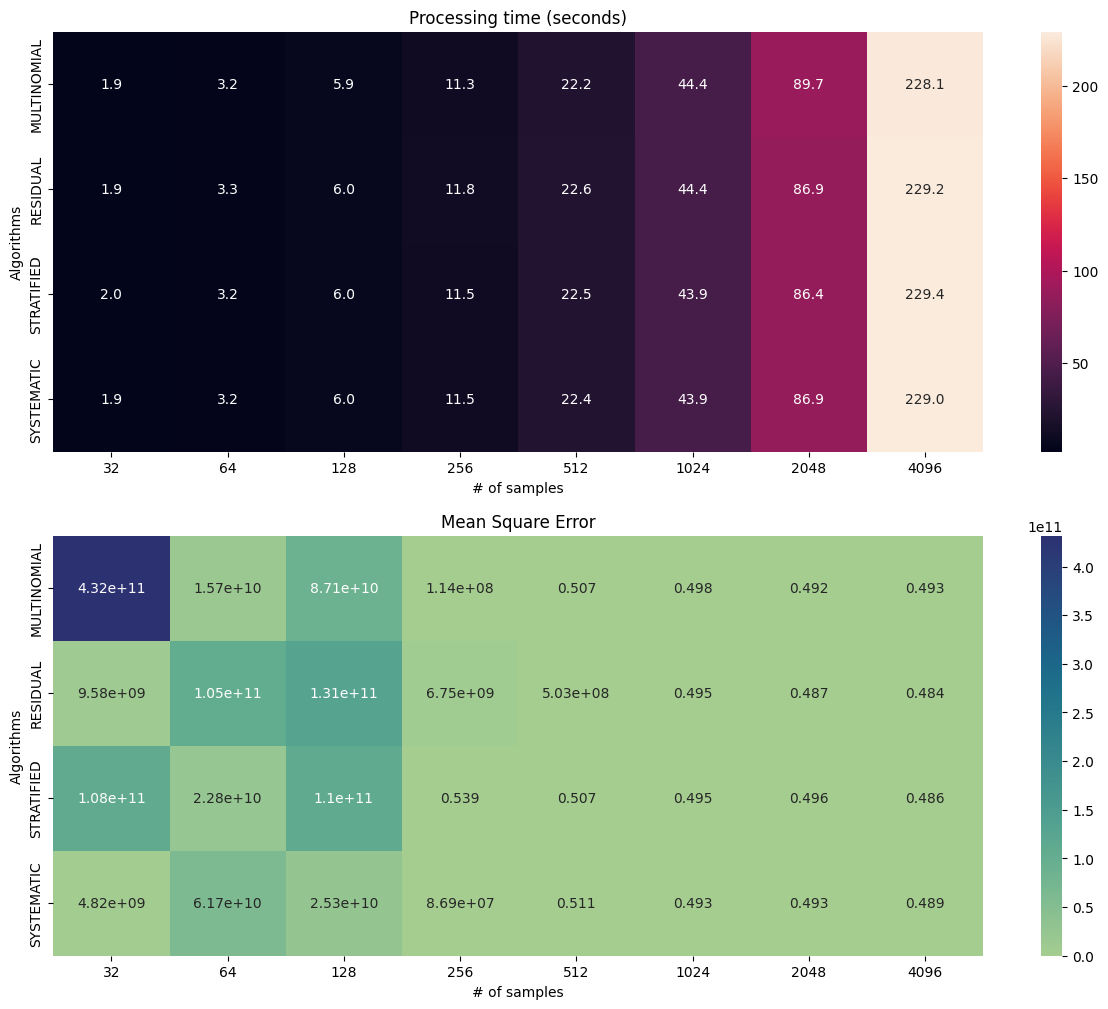

In [11]:
tuner_setup2.plot_results()

In [12]:
n_setup2_0, algorithm_setup2_0 = tuner_setup2.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_0.append([n_setup2_0, resampling_algorithm_str[algorithm_setup2_0]])

Optimal model index: 19
Optimal model error: 0.539 and processing time: 11.5
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.STRATIFIED


## Setup3 (INS)

In [13]:
tuner_setup3 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)
tuner_setup3.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [14]:
tuner_setup3.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:00<00:00, 37.61s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:02<00:00, 37.75s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:03<00:00, 37.99s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:03<00:00, 37.98s/it]


Experiment finished.


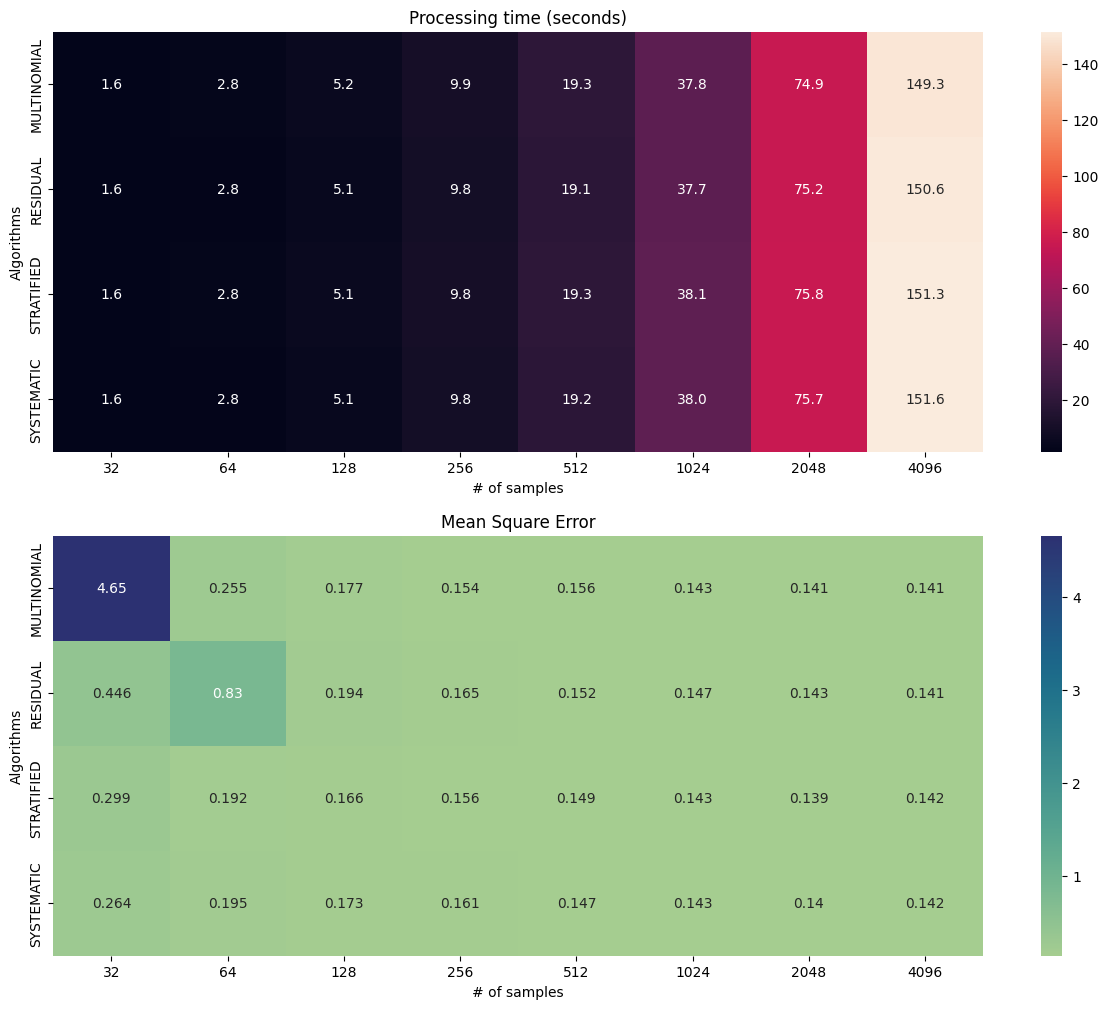

In [15]:
tuner_setup3.plot_results()

In [16]:
n_setup3_0, algorithm_setup3_0 = tuner_setup3.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append([n_setup3_0, resampling_algorithm_str[algorithm_setup3_0]])

Optimal model index: 18
Optimal model error: 0.166 and processing time: 5.1
Optimal model number of samples: 128
Optimal model resampling algorithm: ResamplingAlgorithms.STRATIFIED


# 10% dropout measurement data

## Setup1 (IMU, VO)

In [17]:
tuner_setup1_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

tuner_setup1_10.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [18]:
tuner_setup1_10.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:49<00:00, 28.71s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:51<00:00, 28.96s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.04s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:51<00:00, 28.89s/it]


Experiment finished.


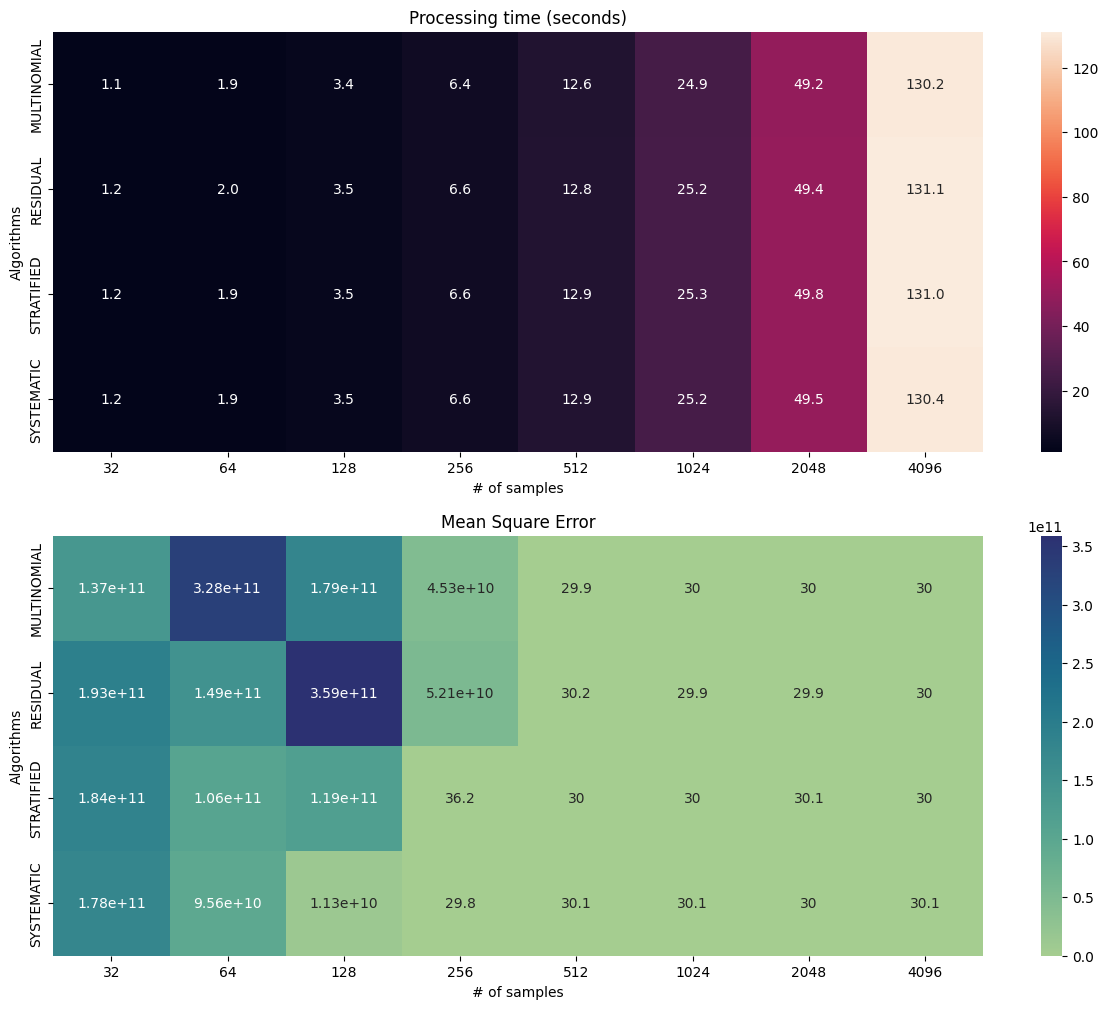

In [19]:
tuner_setup1_10.plot_results()

In [20]:
n_setup1_10, algorithm_setup1_10 = tuner_setup1_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append([n_setup1_10, resampling_algorithm_str[algorithm_setup1_10]])

Optimal model index: 27
Optimal model error: 29.761 and processing time: 6.6
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [21]:
tuner_setup2_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

tuner_setup2_10.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [22]:
tuner_setup2_10.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:42<00:00, 50.29s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:45<00:00, 50.64s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:12<00:00, 54.10s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:37<00:00, 49.67s/it]

Experiment finished.


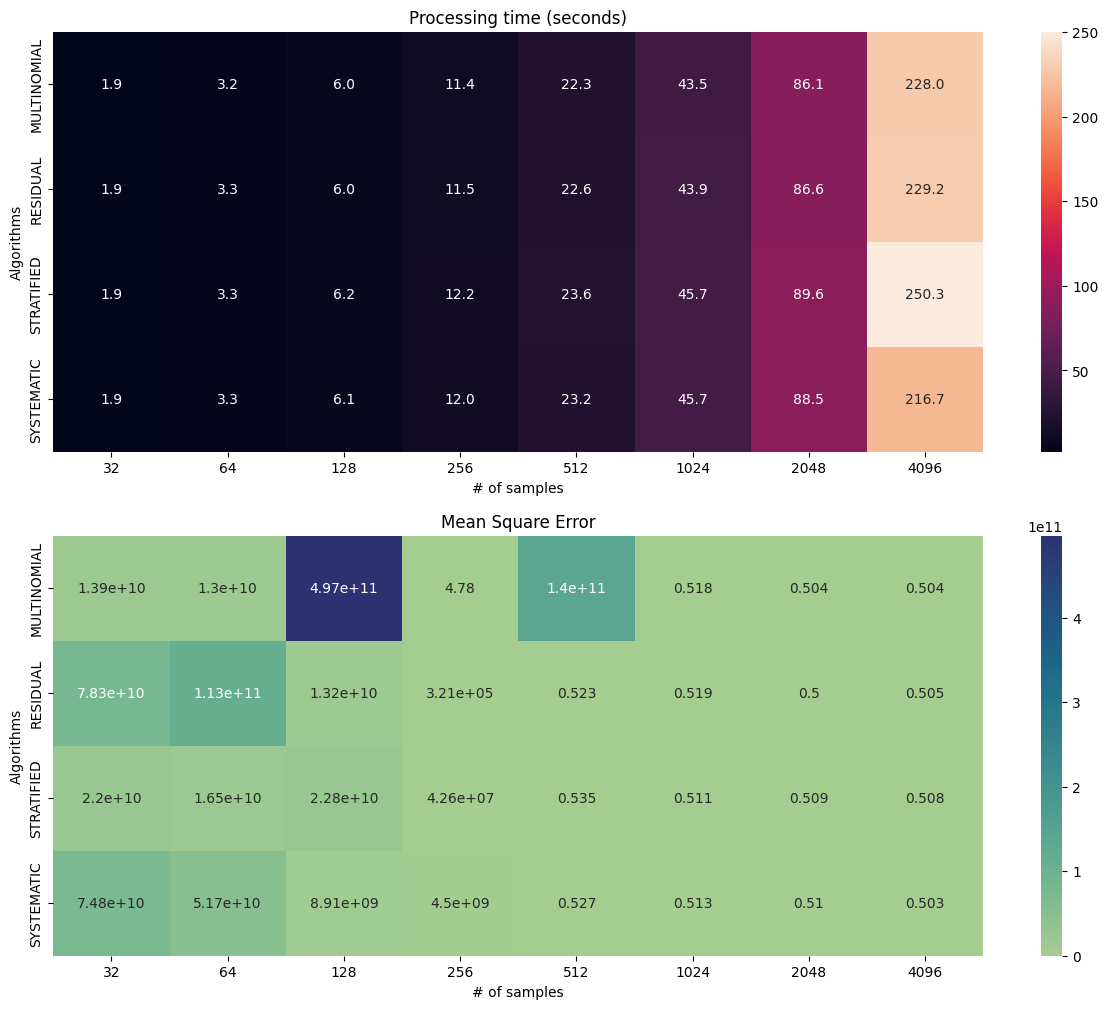

In [23]:
tuner_setup2_10.plot_results()

In [24]:
n_setup2_10, algorithm_setup2_10 = tuner_setup2_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append([n_setup2_10, resampling_algorithm_str[algorithm_setup2_10]])

Optimal model index: 3
Optimal model error: 4.781 and processing time: 11.4
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.MULTINOMIAL


## Setup3 (INS)

In [25]:
tuner_setup3_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

tuner_setup3_10.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [26]:
tuner_setup3_10.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:05<00:00, 38.23s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:09<00:00, 38.63s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:05<00:00, 38.17s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:04<00:00, 38.08s/it]

Experiment finished.


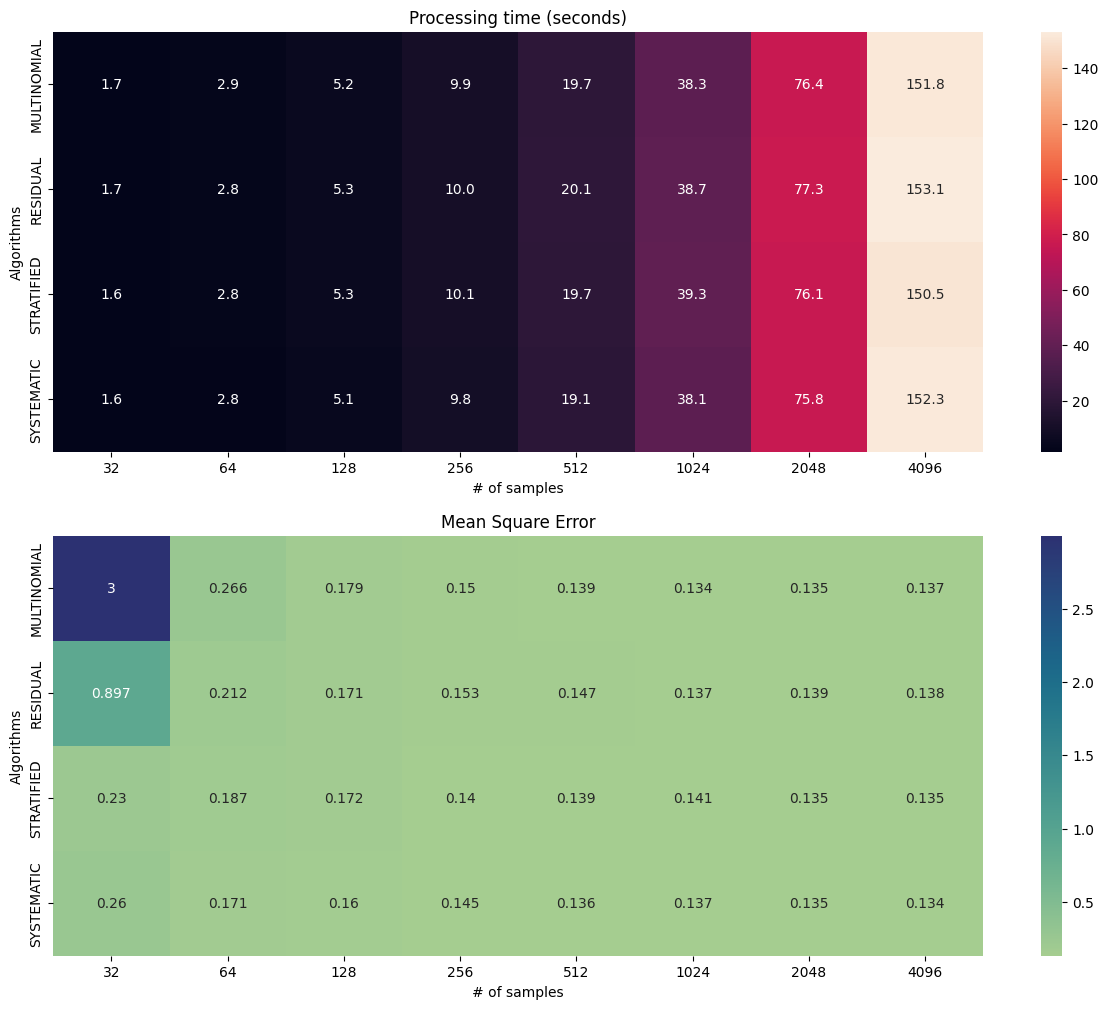

In [27]:
tuner_setup3_10.plot_results()

In [28]:
n_setup3_10, algorithm_setup3_10 = tuner_setup3_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append([n_setup3_10, resampling_algorithm_str[algorithm_setup3_10]])

Optimal model index: 25
Optimal model error: 0.171 and processing time: 2.8
Optimal model number of samples: 64
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


# 20% dropout measurement data

## Setup1 (IMU, VO)

In [29]:
tuner_setup1_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

tuner_setup1_20.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                    upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [30]:
tuner_setup1_20.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:50<00:00, 28.75s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:51<00:00, 28.99s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:53<00:00, 29.18s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.05s/it]

Experiment finished.


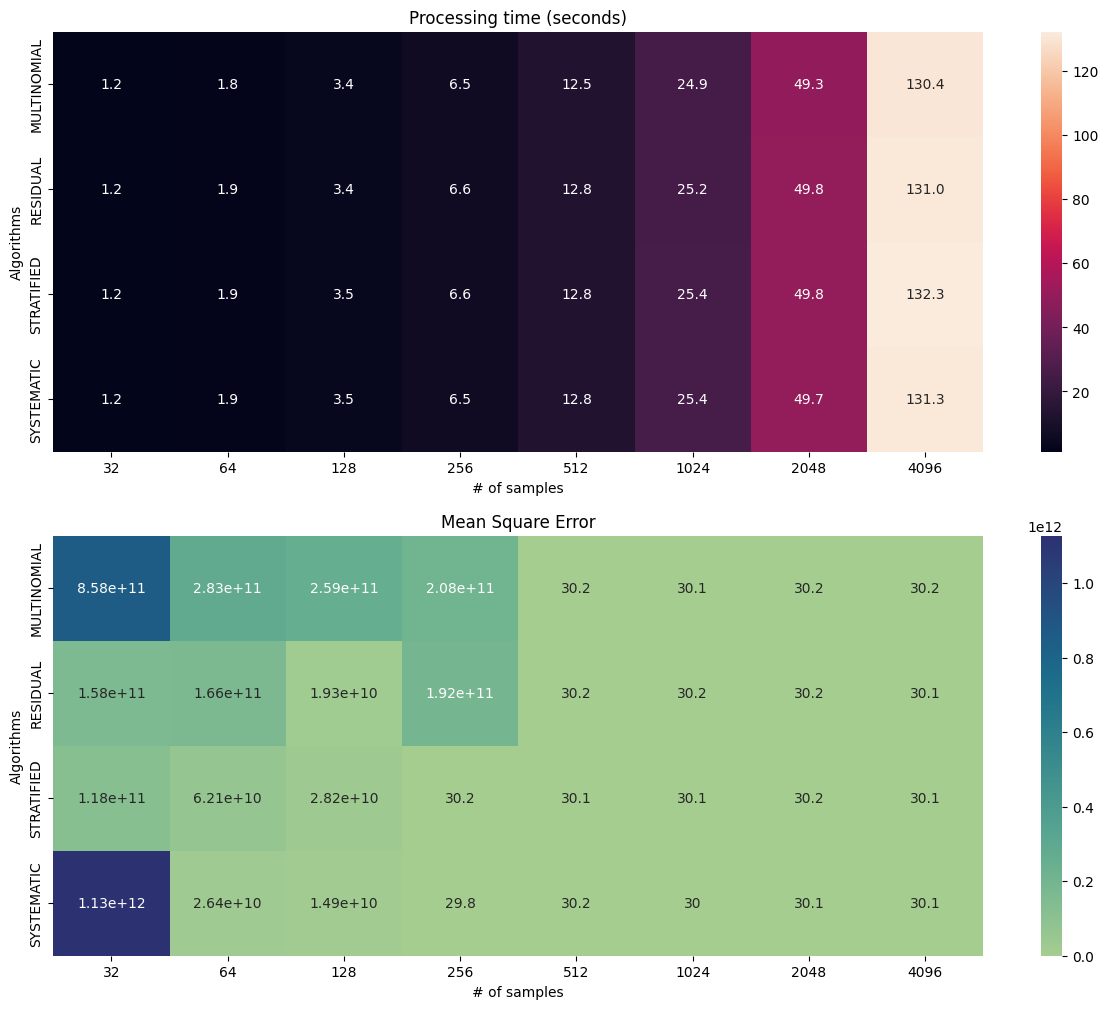

In [31]:
tuner_setup1_20.plot_results()

In [32]:
n_setup1_20, algorithm_setup1_20 = tuner_setup1_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append([n_setup1_20, resampling_algorithm_str[algorithm_setup1_20]])

Optimal model index: 27
Optimal model error: 29.803 and processing time: 6.5
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [33]:
tuner_setup2_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

tuner_setup2_20.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [34]:
tuner_setup2_20.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:40<00:00, 50.07s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:44<00:00, 50.57s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:48<00:00, 51.06s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:48<00:00, 51.06s/it]

Experiment finished.


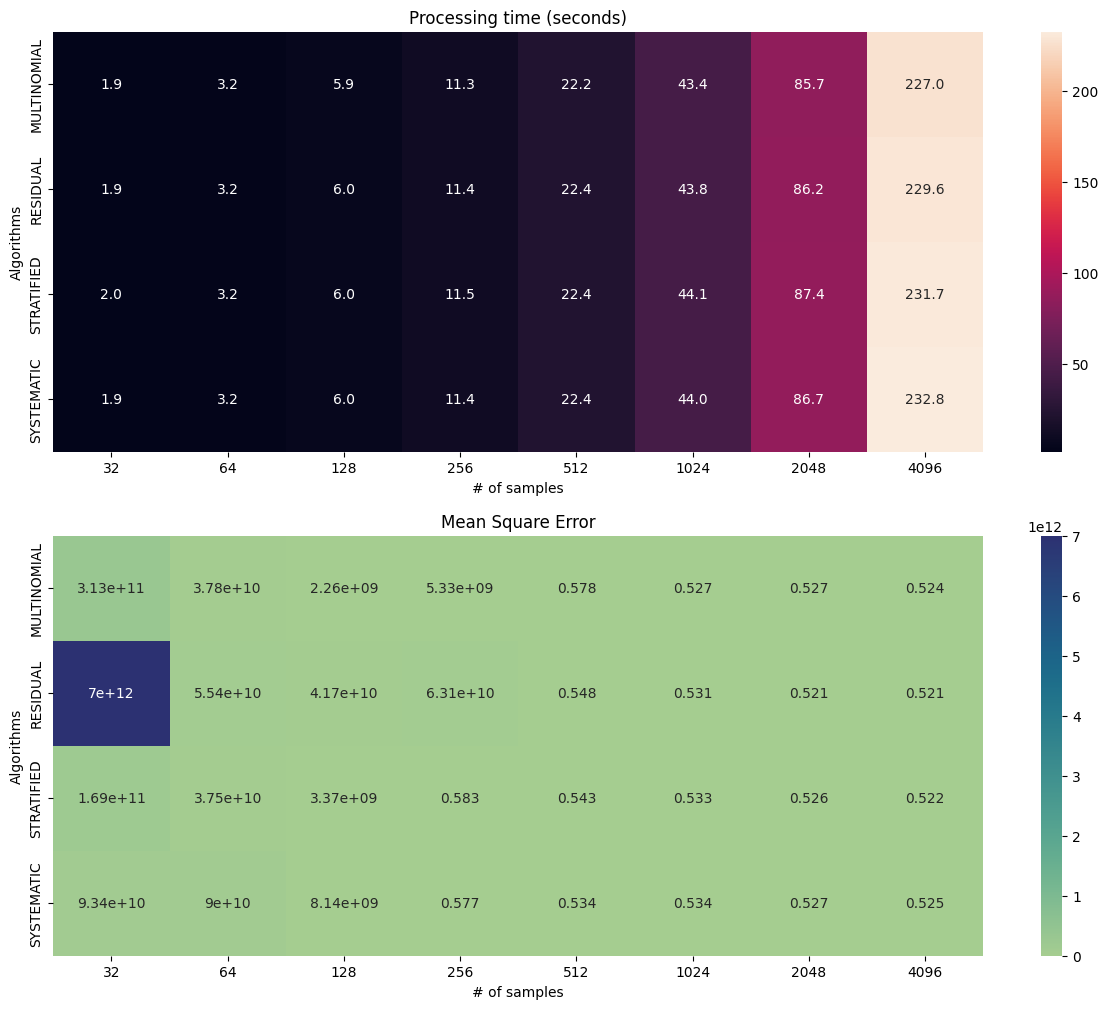

In [35]:
tuner_setup2_20.plot_results()

In [36]:
n_setup2_20, algorithm_setup2_20 = tuner_setup2_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append([n_setup2_20, resampling_algorithm_str[algorithm_setup2_20]])

Optimal model index: 27
Optimal model error: 0.577 and processing time: 11.4
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


## Setup3 (INS)

In [37]:
tuner_setup3_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

tuner_setup3_20.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [38]:
tuner_setup3_20.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.63s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:59<00:00, 37.49s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:02<00:00, 37.86s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:03<00:00, 37.97s/it]

Experiment finished.


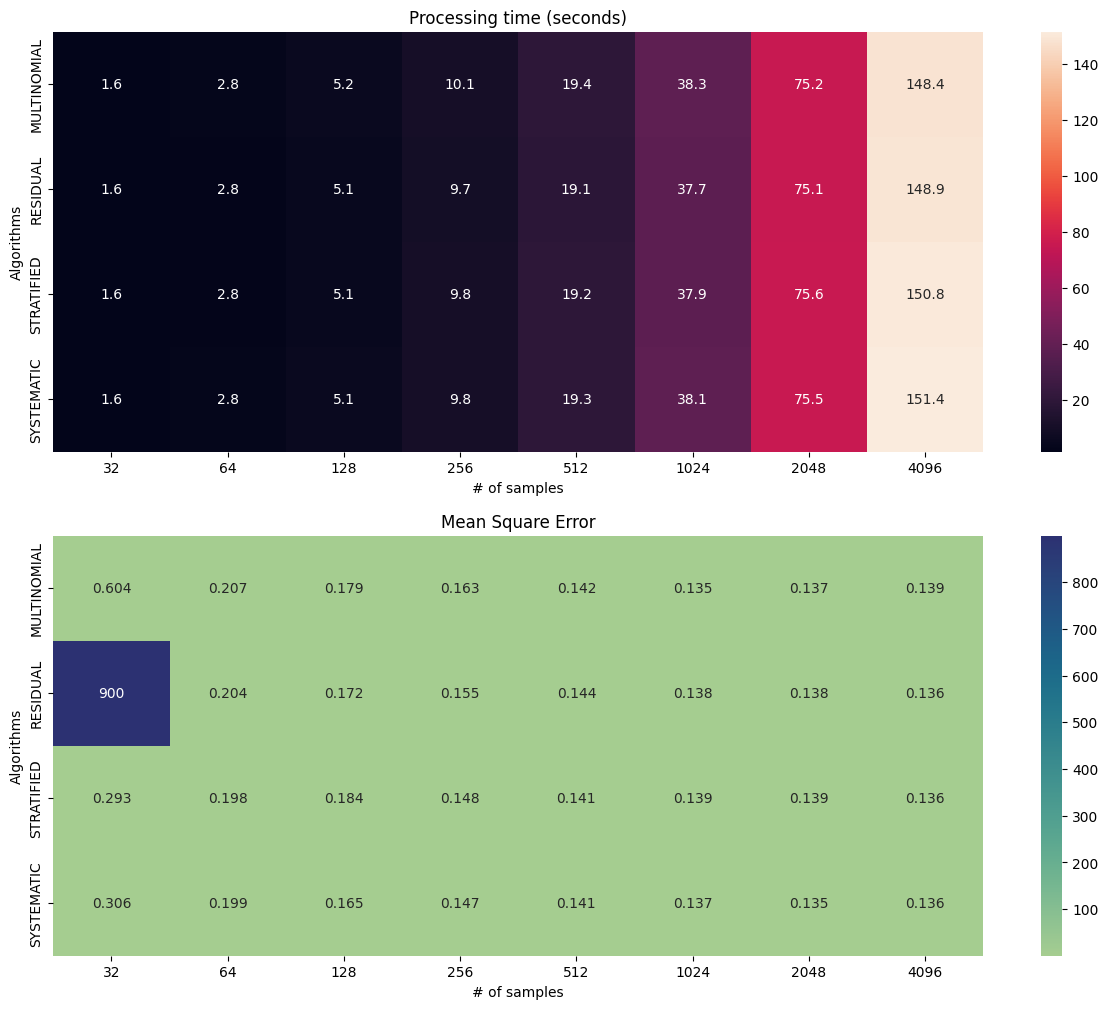

In [39]:
tuner_setup3_20.plot_results()

In [40]:
n_setup3_20, algorithm_setup3_20 = tuner_setup3_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append([n_setup3_20, resampling_algorithm_str[algorithm_setup3_20]])

Optimal model index: 24
Optimal model error: 0.306 and processing time: 1.6
Optimal model number of samples: 32
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


# 30% dropout measurement data

## Setup1 (IMU, VO)

In [41]:
tuner_setup1_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)

tuner_setup1_30.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [42]:
tuner_setup1_30.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:47<00:00, 28.42s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:56<00:00, 29.55s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:56<00:00, 29.60s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:13<00:00, 31.64s/it]

Experiment finished.


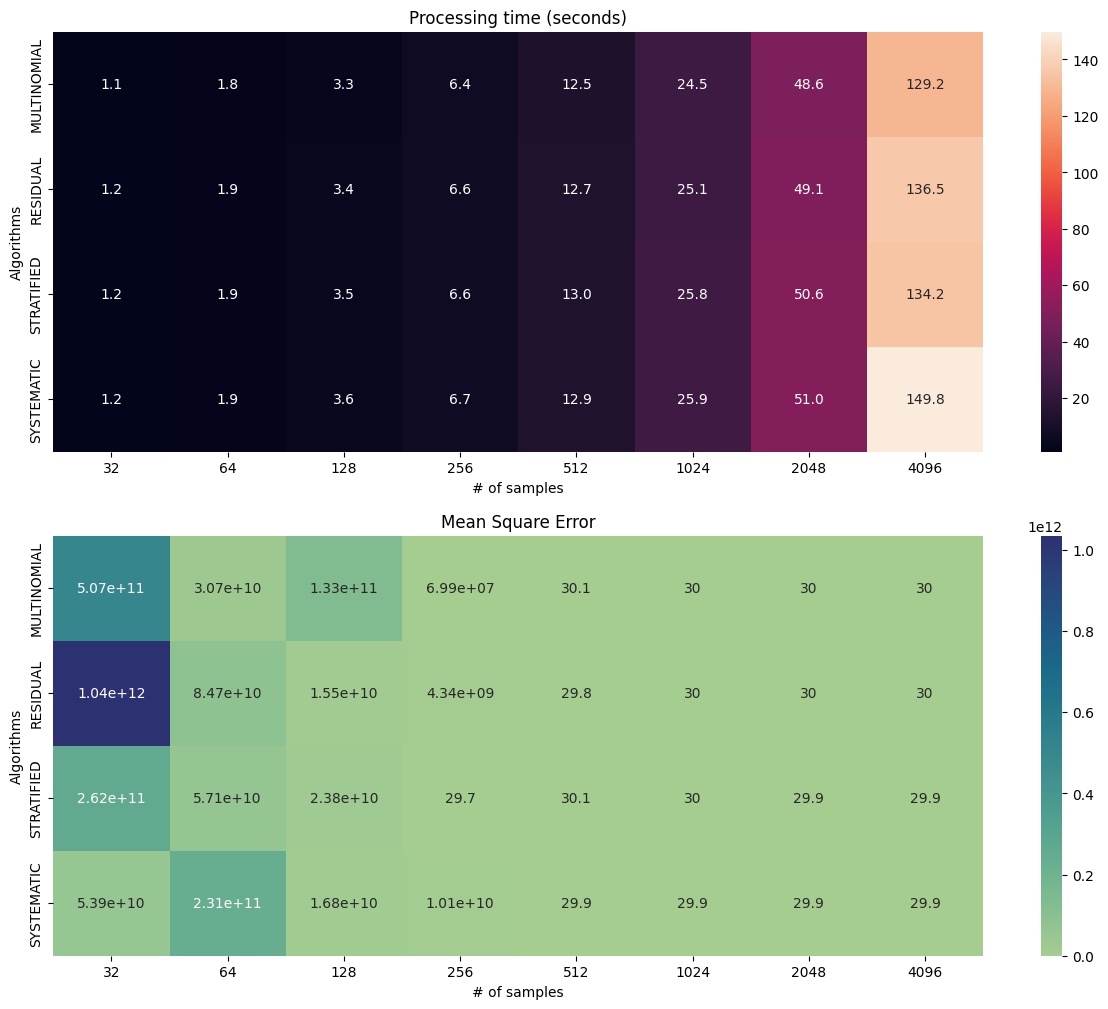

In [43]:
tuner_setup1_30.plot_results()

In [44]:
n_setup1_30, algorithm_setup1_30 = tuner_setup1_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append([n_setup1_30, resampling_algorithm_str[algorithm_setup1_30]])

Optimal model index: 19
Optimal model error: 29.684 and processing time: 6.6
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.STRATIFIED


## Setup2 (IMU, VO+GPS)

In [45]:
tuner_setup2_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)
tuner_setup2_30.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [46]:
tuner_setup2_30.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:11<00:00, 53.88s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:00<00:00, 52.56s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:45<00:00, 50.65s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:53<00:00, 51.73s/it]

Experiment finished.


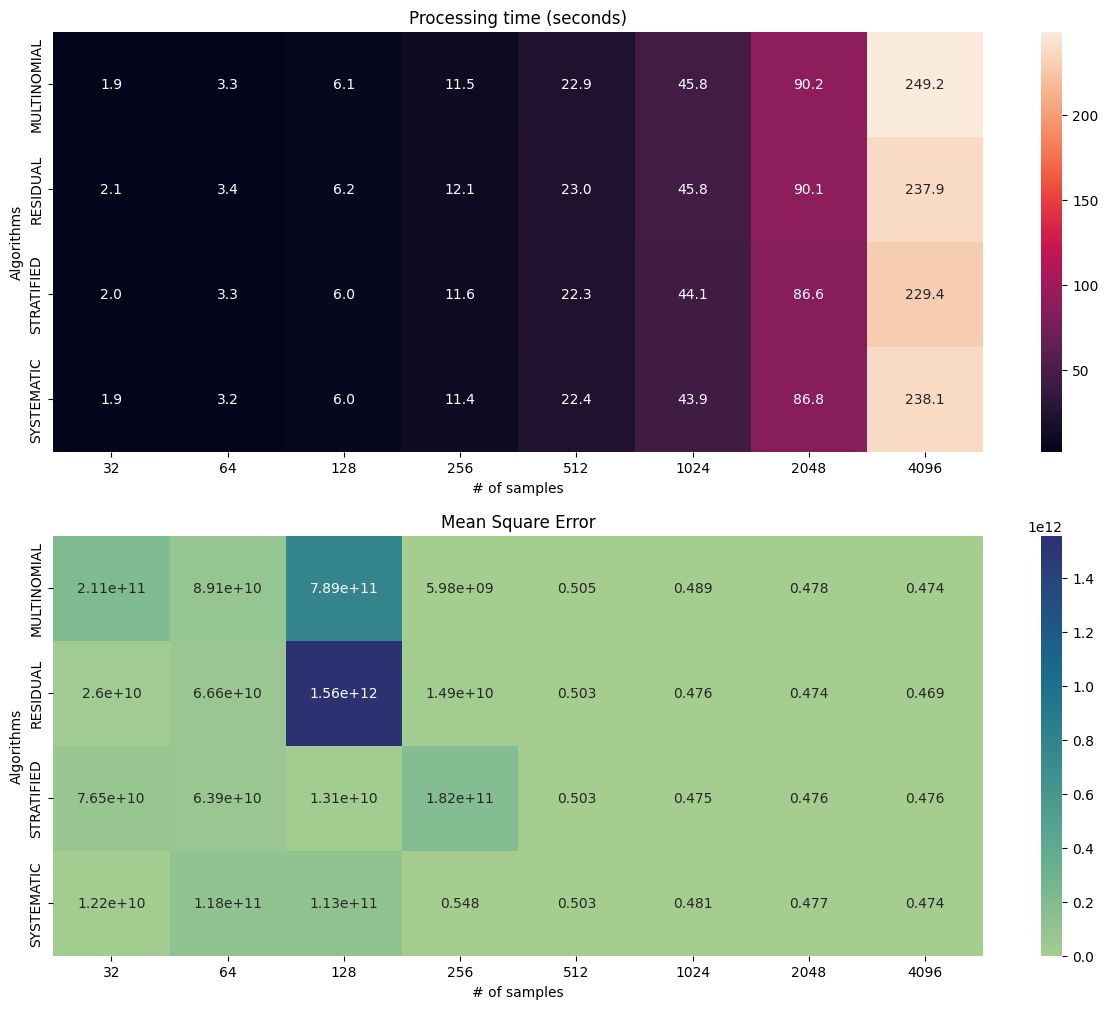

In [47]:
tuner_setup2_30.plot_results()

In [48]:
n_setup2_30, algorithm_setup2_30 = tuner_setup2_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append([n_setup2_30, resampling_algorithm_str[algorithm_setup2_30]])

Optimal model index: 27
Optimal model error: 0.548 and processing time: 11.4
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


## Setup3 (INS)

In [49]:
tuner_setup3_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)

tuner_setup3_30.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [50]:
tuner_setup3_30.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:08<00:00, 38.58s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:11<00:00, 38.91s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:14<00:00, 39.26s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:12<00:00, 39.09s/it]

Experiment finished.


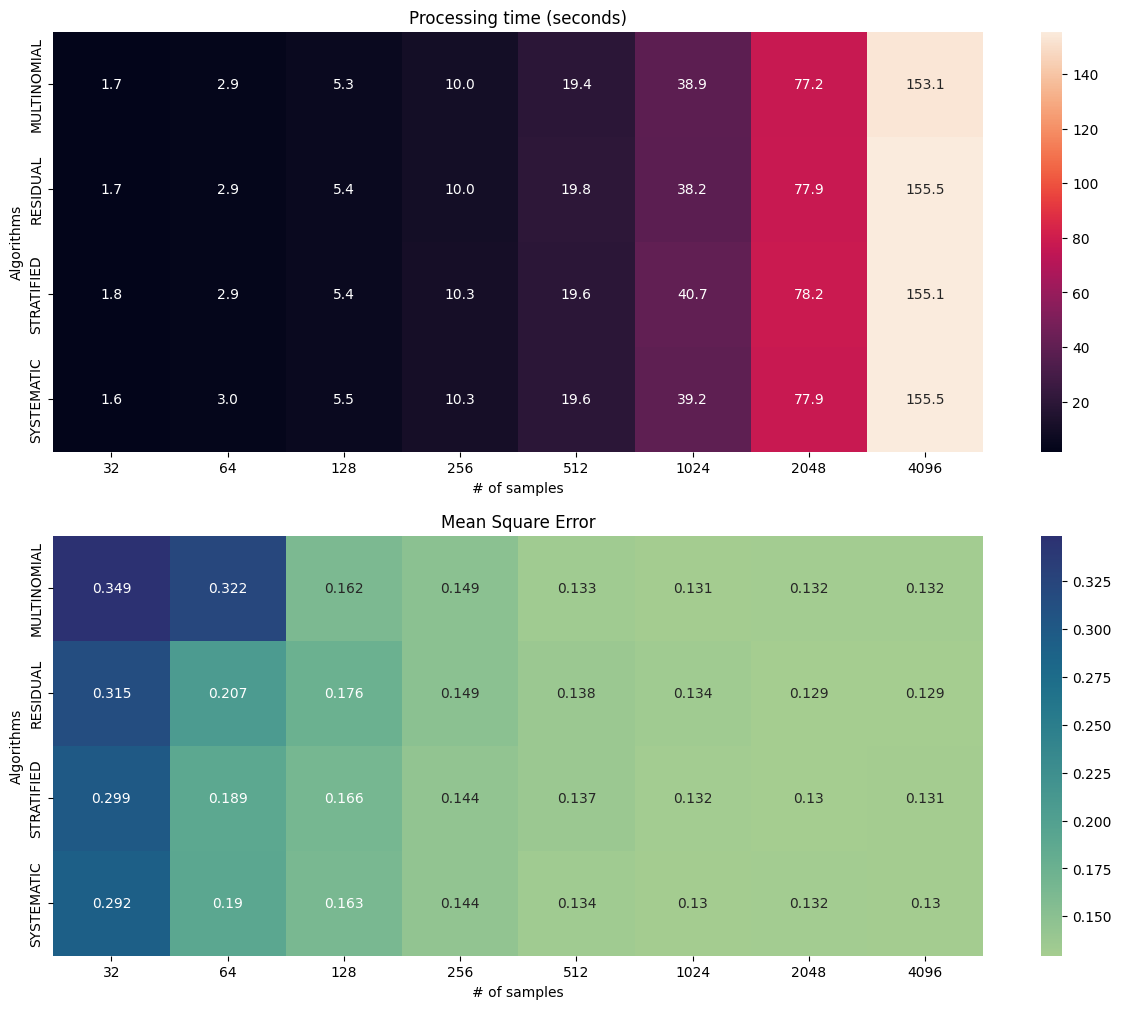

In [51]:
tuner_setup3_30.plot_results()

In [52]:
n_setup3_30, algorithm_setup3_30 = tuner_setup3_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append([n_setup3_30, resampling_algorithm_str[algorithm_setup3_30]])

Optimal model index: 4
Optimal model error: 0.133 and processing time: 19.4
Optimal model number of samples: 512
Optimal model resampling algorithm: ResamplingAlgorithms.MULTINOMIAL


# 40% dropout measurement data

## Setup1 (IMU, VO)

In [53]:
tuner_setup1_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

tuner_setup1_40.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [54]:
tuner_setup1_40.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:08<00:00, 31.12s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:06<00:00, 30.85s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:07<00:00, 30.90s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:17<00:00, 32.19s/it]

Experiment finished.


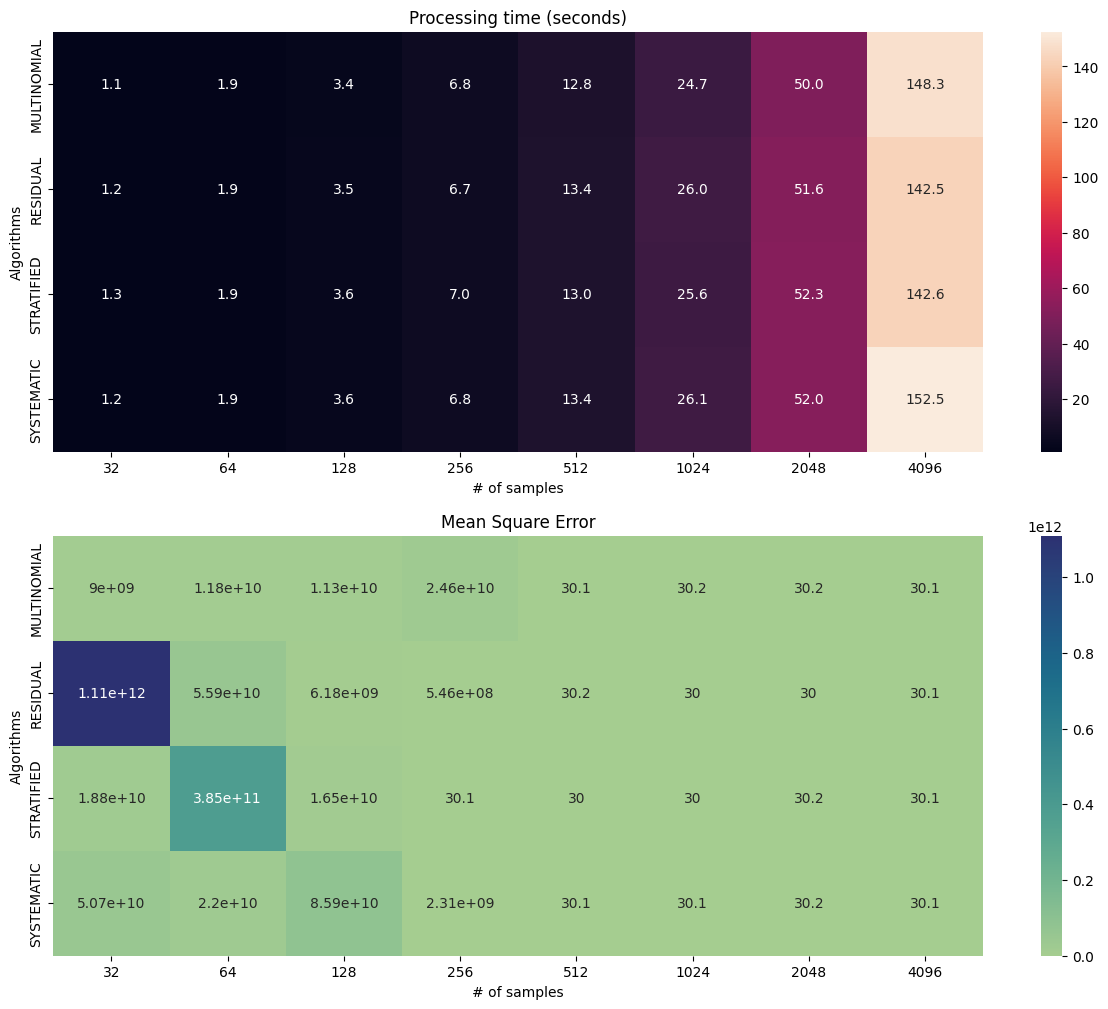

In [55]:
tuner_setup1_40.plot_results()

In [56]:
n_setup1_40, algorithm_setup1_40 = tuner_setup1_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append([n_setup1_40, resampling_algorithm_str[algorithm_setup1_40]])

Optimal model index: 19
Optimal model error: 30.088 and processing time: 7.0
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.STRATIFIED


## Setup2 (IMU, VO+GPS)

In [57]:
tuner_setup2_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

tuner_setup2_40.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [58]:
tuner_setup2_40.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:01<00:00, 52.67s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:14<00:00, 54.26s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:07<00:00, 53.40s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:48<00:00, 51.12s/it]


Experiment finished.


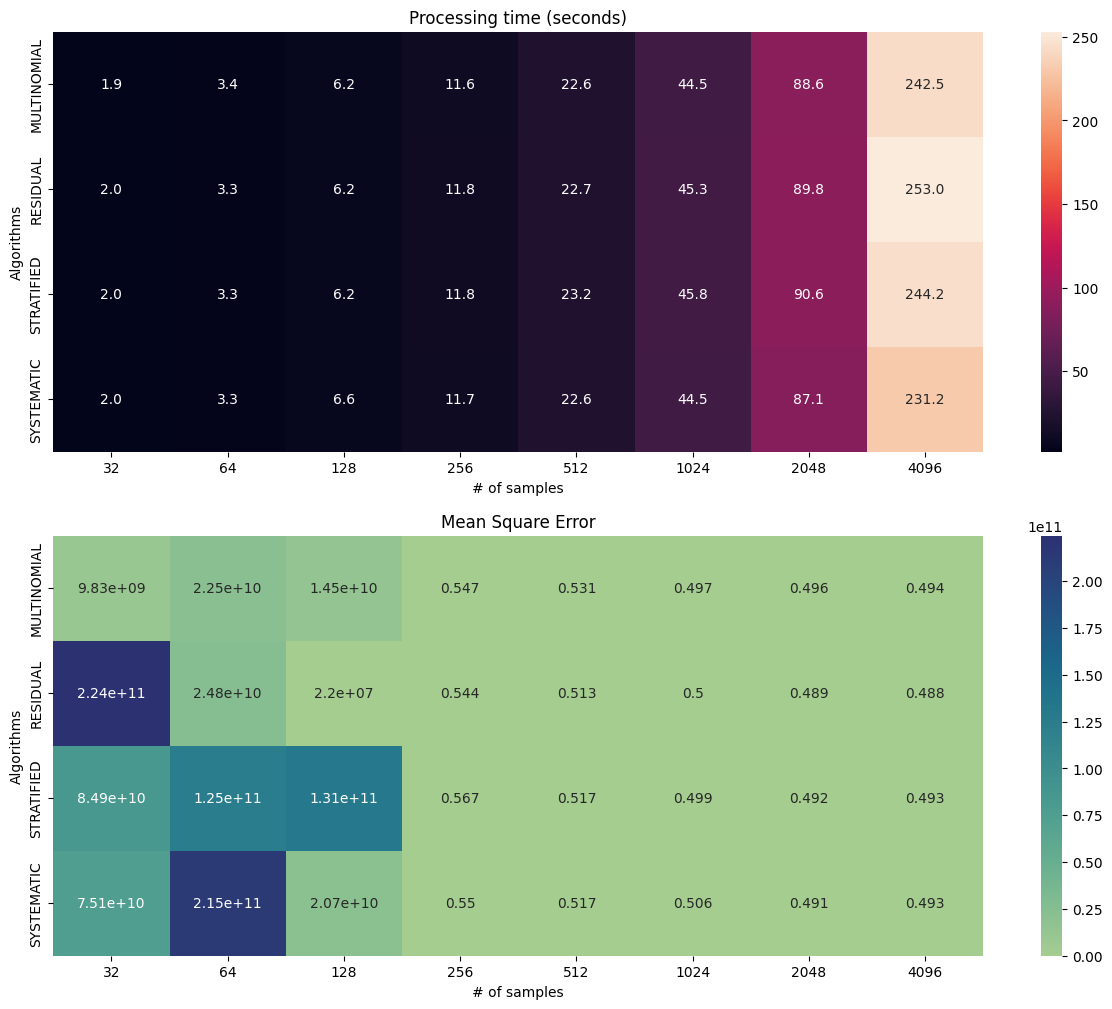

In [59]:
tuner_setup2_40.plot_results()

In [60]:
n_setup2_40, algorithm_setup2_40 = tuner_setup2_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append([n_setup2_40, resampling_algorithm_str[algorithm_setup2_40]])

Optimal model index: 3
Optimal model error: 0.547 and processing time: 11.6
Optimal model number of samples: 256
Optimal model resampling algorithm: ResamplingAlgorithms.MULTINOMIAL


## Setup3 (INS)

In [61]:
tuner_setup3_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

tuner_setup3_40.change_data_sampling(sampling=SamplingEnum.UPSAMPLED_DATA, 
                                  upsampling_factor=upsampling_factor)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


In [62]:
tuner_setup3_40.run()

Resampling by $MULTINOMIAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:04<00:00, 38.01s/it]


Resampling by $RESIDUAL


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:02<00:00, 37.77s/it]


Resampling by $STRATIFIED


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:04<00:00, 38.12s/it]


Resampling by $SYSTEMATIC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:04<00:00, 38.06s/it]

Experiment finished.


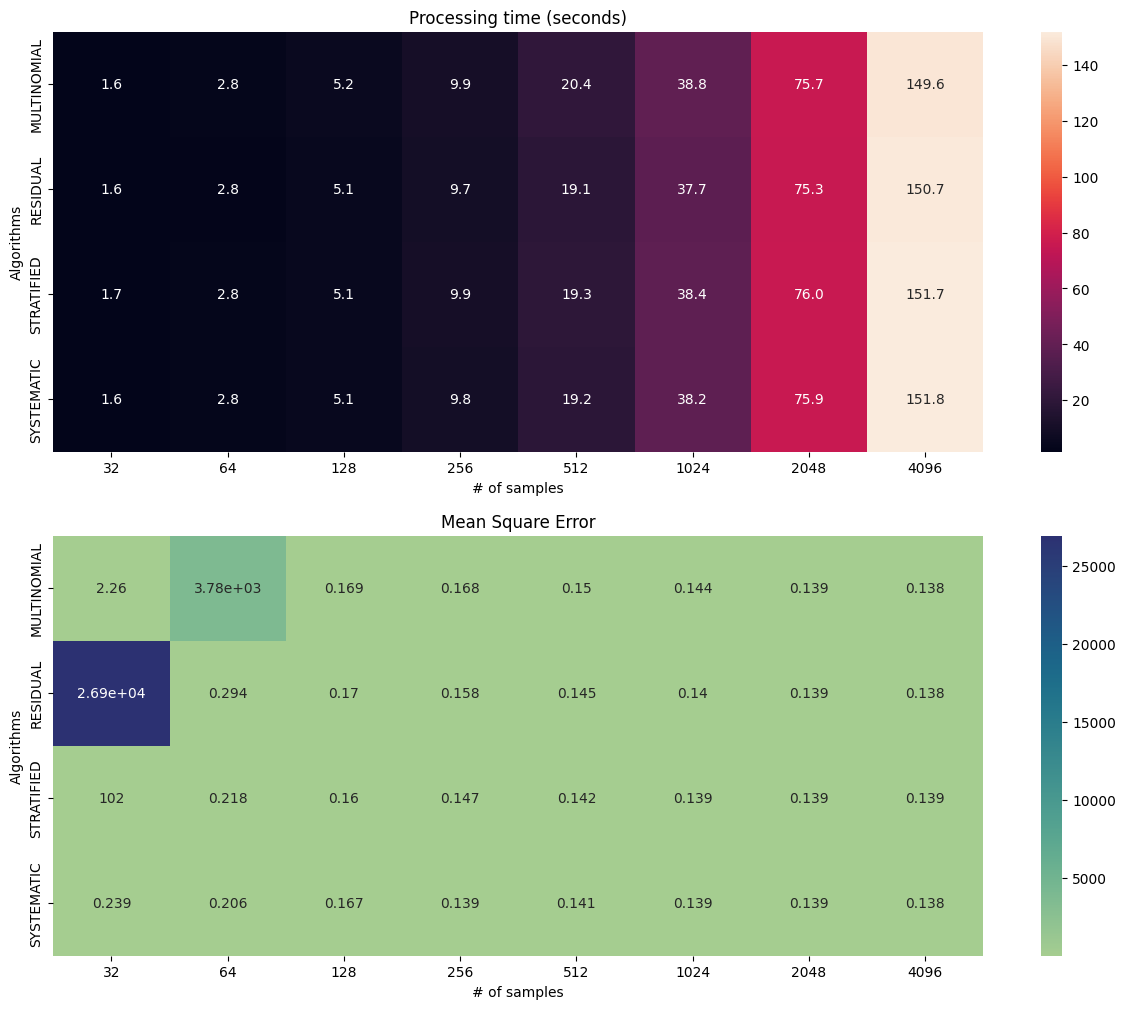

In [63]:
tuner_setup3_40.plot_results()

In [64]:
n_setup3_40, algorithm_setup3_40 = tuner_setup3_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append([n_setup3_40, resampling_algorithm_str[algorithm_setup3_40]])

Optimal model index: 24
Optimal model error: 0.239 and processing time: 1.6
Optimal model number of samples: 32
Optimal model resampling algorithm: ResamplingAlgorithms.SYSTEMATIC


# Results

In [65]:
best_params.append(np.array(best_params_0).flatten().tolist())
best_params.append(np.array(best_params_10).flatten().tolist())
best_params.append(np.array(best_params_20).flatten().tolist())
best_params.append(np.array(best_params_30).flatten().tolist())
best_params.append(np.array(best_params_40).flatten().tolist())
best_params

[['256', 'RESIDUAL', '256', 'STRATIFIED', '128', 'STRATIFIED'],
 ['256', 'SYSTEMATIC', '256', 'MULTINOMIAL', '64', 'SYSTEMATIC'],
 ['256', 'SYSTEMATIC', '256', 'SYSTEMATIC', '32', 'SYSTEMATIC'],
 ['256', 'STRATIFIED', '256', 'SYSTEMATIC', '512', 'MULTINOMIAL'],
 ['256', 'STRATIFIED', '256', 'MULTINOMIAL', '32', 'SYSTEMATIC']]

In [66]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)'],
                                             ['# of samples', 'Resampling algorithm']],
                                            names=['Setups','Parameters'])


In [67]:
pd.DataFrame(best_params, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              256             RESIDUAL                 256   
10% drop                256           SYSTEMATIC                 256   
20% drop                256           SYSTEMATIC                 256   
30% drop                256           STRATIFIED                 256   
40% drop                256           STRATIFIED                 256   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          128           STRATIFIED  
10% drop            MULTINOMIAL           64           SYSTEMATIC  
20% drop             SYSTEMATIC           32           SYSTEMATIC  
30% drop             SYSTEMATIC          512          MULTINOMIAL  
40% drop            MULTINOMIAL           32           SYSTEMATIC